In [2]:

import numpy as np
import pandas as pd
import xarray as xr
from pathlib import Path
from scipy.interpolate import interp1d
from scipy.special import expit
import json
import time
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt

from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             recall_score, precision_score)
from sklearn.utils import check_random_state

import cedalion
import cedalion.nirs
import cedalion.data
import cedalion.sigproc.quality as quality
import cedalion.sigproc.motion_correct as motion_correct
from cedalion.nirs import channel_distances
from cedalion import units


# -- KONFIGURACJA --------------------------------------------------------------
DATA_DIR    = r"/Users/antek/Desktop/Praca Magisterska kody/Dane"
FILE_PREFIX = "SITTING"
OUTDIR      = Path(r"/Users/antek/Desktop/Praca Magisterska kody/LOSO")
OUTDIR.mkdir(parents=True, exist_ok=True)

SNR_THRESHOLD = 10
FMIN, FMAX, BUTTER_ORDER = 0.01, 0.2, 4
DPF_VALUE = 6.0
BEFORE_S, AFTER_S = 0.0, 19.0

N_PERMUTATIONS = 200
RANDOM_SEED = 0


def strip_pint(da):
    vals = da.values
    if hasattr(vals, "magnitude"):
        vals = vals.magnitude
    coord_attrs = {k: da[k].attrs.copy() for k in da.coords}
    result = xr.DataArray(vals, dims=da.dims, coords=da.coords, attrs=da.attrs)
    for k, attrs in coord_attrs.items():
        result[k].attrs = attrs
    return result


def od_to_hb(od, geo3d):
    """OD -> [HbO, HbR] (obie chromofory)."""
    od = strip_pint(od)
    path = cedalion.data.get("prahl_absorption_spectrum.tsv")
    with path.open("r") as fin:
        coeffs = np.loadtxt(fin, comments="#")
    wls = od.wavelength.values.astype(float)
    spectra = [interp1d(coeffs[:, 0], np.log(10) * coeffs[:, i] / 10) for i in [1, 2]]
    E_vals = np.array([s(wl) for s in spectra for wl in wls]).reshape(2, len(wls))
    E = xr.DataArray(E_vals, dims=["chromo", "wavelength"],
                     coords={"chromo": ["HbO", "HbR"], "wavelength": od.wavelength})
    Einv = xr.DataArray(np.linalg.pinv(E.values), dims=["wavelength", "chromo"],
                        coords={"wavelength": od.wavelength, "chromo": ["HbO", "HbR"]})
    dists = strip_pint(channel_distances(od, geo3d))
    dpf = xr.DataArray(np.full(len(wls), DPF_VALUE), dims=["wavelength"],
                       coords={"wavelength": od.wavelength})
    od_norm = od / (dists * dpf)
    hb = xr.dot(Einv, od_norm, dim="wavelength")
    hb["time"].attrs = od["time"].attrs
    return hb


def preprocess_one(file_path):
    rec = cedalion.io.read_snirf(str(file_path))[0]
    rec.stim.cd.rename_events({"1": "MC", "2": "REST"})
    stim = rec.stim.sort_values("onset").reset_index(drop=True)
    stim = stim[stim["trial_type"].isin(["MC", "REST"])].reset_index(drop=True)
    onsets = stim["onset"].astype(float).to_numpy()
    durs = np.diff(onsets, append=onsets[-1])
    durs[-1] = max(1.0, durs[-2])
    stim["duration"] = durs

    amp = rec["amp"]
    amp = amp - float(amp.min()) + 1e-12
    _, snr_mask = quality.snr(amp, SNR_THRESHOLD)
    amp, _ = quality.prune_ch(amp, snr_mask.expand_dims(label=["snr"]), "any")

    od = cedalion.nirs.int2od(amp)
    od = motion_correct.tddr(od)
    od = motion_correct.motion_correct_wavelet(od)
    od = od.cd.freq_filter(fmin=FMIN, fmax=FMAX, butter_order=BUTTER_ORDER)

    hb = od_to_hb(od, rec.geo3d)
    channels = list(hb.channel.values.astype(str))
    return {"subject": file_path.stem, "hb": hb, "stim": stim, "channels": channels}


def extract_epochs_array(item, common_channels):
    hb = item["hb"].sel(channel=common_channels)
    epochs = hb.cd.to_epochs(
        item["stim"], ["MC", "REST"],
        before=BEFORE_S * units.s, after=AFTER_S * units.s,
    )
    epochs = epochs.transpose("epoch", "chromo", "channel", "reltime")
    X = epochs.values
    if hasattr(X, "magnitude"):
        X = X.magnitude
    y = epochs.trial_type.values.astype(str)
    finite_mask = np.all(np.isfinite(X.reshape(X.shape[0], -1)), axis=1)
    X, y = X[finite_mask], y[finite_mask]
    t = epochs.reltime.values.astype(float)
    fs = 1.0 / np.median(np.diff(t))
    subj_id = np.array([item["subject"]] * len(X))
    return X, y, subj_id, fs

files = sorted(Path(DATA_DIR).glob(f"{FILE_PREFIX}*.snirf"))
print(f"Znaleziono {len(files)} plikow.")

cache = []
for f in files:
    try:
        cache.append(preprocess_one(f))
        print(f"  OK: {f.stem}")
    except Exception as e:
        print(f"  FAIL {f.stem}: {e}")

# wspolne kanaly (intersection)
sets = [set(item["channels"]) for item in cache]
common_channels = sorted(set.intersection(*sets))
print(f"\nCommon channels: {len(common_channels)} "
      f"(min per subj = {min(len(s) for s in sets)}, "
      f"max per subj = {max(len(s) for s in sets)})")

Xs, ys, ss, fs_list = [], [], [], []
for item in cache:
    try:
        X_, y_, s_, fs_ = extract_epochs_array(item, common_channels)
        if len(X_) > 0:
            Xs.append(X_); ys.append(y_); ss.append(s_); fs_list.append(fs_)
    except Exception as e:
        print(f"  [WARN epoch] {item['subject']}: {e}")

X_all   = np.concatenate(Xs, axis=0)     # (N, 2, K, T) chromo=[HbO,HbR]
y_all   = np.concatenate(ys, axis=0)     # "MC" / "REST"
subj_all = np.concatenate(ss, axis=0)
FS      = float(np.median(fs_list))
N_CHROMO, N_CHANNELS, N_SAMPLES = X_all.shape[1], X_all.shape[2], X_all.shape[3]

print(f"\nX_all shape: {X_all.shape}")
print(f"MC: {np.sum(y_all == 'MC')}, REST: {np.sum(y_all == 'REST')}")
print(f"Subjects: {len(np.unique(subj_all))}, fs = {FS:.2f} Hz")


def summary_metrics(y_true, y_pred, y_proba=None):
    mask = np.isin(y_true, ["MC", "REST"])
    y_true, y_pred = y_true[mask], y_pred[mask]
    if len(y_true) == 0:
        return {"accuracy": np.nan, "balanced_accuracy": np.nan,
                "f1_macro": np.nan, "f1_MC": np.nan,
                "recall_MC": np.nan, "precision_MC": np.nan,
                "n": 0, "roc_auc": np.nan}
    out = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro",
                             labels=["MC", "REST"], zero_division=0),
        "f1_MC": f1_score(y_true, y_pred, pos_label="MC", average="binary",
                          labels=["MC", "REST"], zero_division=0),
        "recall_MC": recall_score(y_true, y_pred, pos_label="MC",
                                  labels=["MC", "REST"], zero_division=0),
        "precision_MC": precision_score(y_true, y_pred, pos_label="MC",
                                        labels=["MC", "REST"], zero_division=0),
        "n": len(y_true), "roc_auc": np.nan,
    }
    if y_proba is not None and len(np.unique(y_true)) == 2:
        try:
            out["roc_auc"] = roc_auc_score((y_true == "MC").astype(int), y_proba[mask])
        except Exception:
            pass
    return out


def run_loso(X, y, subj, fit_predict_fn, method_name, need_proba=True):
    per, y_true_all, y_pred_all, y_proba_all = [], [], [], []
    for s in np.unique(subj):
        te, tr = (subj == s), (subj != s)
        try:
            out = fit_predict_fn(X[tr], y[tr], X[te])
        except Exception as e:
            print(f"  [LOSO] {method_name} | subject {s} FAILED: {e}")
            continue
        y_pred = out["y_pred"]
        y_proba = out.get("y_proba", None)
        m = summary_metrics(y[te], y_pred, y_proba if need_proba else None)
        m["subject"] = str(s)
        per.append(m)
        y_true_all.append(y[te]); y_pred_all.append(y_pred)
        if need_proba and y_proba is not None:
            y_proba_all.append(y_proba)

    per_df = pd.DataFrame(per)
    y_true_all = np.concatenate(y_true_all) if y_true_all else np.array([])
    y_pred_all = np.concatenate(y_pred_all) if y_pred_all else np.array([])
    y_proba_all = (np.concatenate(y_proba_all)
                   if (need_proba and y_proba_all) else None)
    pooled_acc = accuracy_score(y_true_all, y_pred_all) if len(y_true_all) else np.nan
    return {
        "method": method_name,
        "per_subject": per_df,
        "y_true": y_true_all, "y_pred": y_pred_all, "y_proba": y_proba_all,
        "pooled_acc": pooled_acc,
    }



def plot_and_save(res, perm_null=None, p_value=None, channel_importance=None,
                  channels=None, outdir=OUTDIR):
    name = res["method"]
    sub = outdir / name
    sub.mkdir(parents=True, exist_ok=True)

    res["per_subject"].to_csv(sub / f"{name}_per_subject.csv", index=False)
    metrics = summary_metrics(res["y_true"], res["y_pred"], res["y_proba"])
    summary = {
        "method": name, **metrics,
        "n_subjects": int(res["per_subject"].shape[0]),
        "mean_acc_over_subjects": float(res["per_subject"]["accuracy"].mean()),
        "std_acc_over_subjects": float(res["per_subject"]["accuracy"].std()),
        "pooled_acc": res["pooled_acc"],
        "p_value_vs_chance": p_value,
    }
    with open(sub / f"{name}_summary.json", "w") as f:
        json.dump(summary, f, indent=2, default=str)

    cm = confusion_matrix(res["y_true"], res["y_pred"], labels=["MC", "REST"])
    fig, ax = plt.subplots(figsize=(4, 3.5))
    im = ax.imshow(cm, cmap="Blues")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["MC", "REST"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["MC", "REST"])
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(f"{name}  (acc={metrics['accuracy']:.3f})")
    plt.colorbar(im, ax=ax); plt.tight_layout()
    fig.savefig(sub / f"{name}_confusion.png", dpi=150); plt.show(); plt.close(fig)

    df = res["per_subject"].sort_values("accuracy")
    fig, ax = plt.subplots(figsize=(max(6, len(df) * 0.3), 3.5))
    ax.bar(df["subject"], df["accuracy"], color="steelblue")
    ax.axhline(0.5, ls="--", color="red", label="chance")
    ax.set_ylabel("LOSO accuracy"); ax.set_xlabel("Subject (held out)")
    ax.set_title(f"{name}: per-subject accuracy"); ax.set_ylim(0, 1)
    plt.xticks(rotation=45, ha="right", fontsize=7); ax.legend()
    plt.tight_layout(); fig.savefig(sub / f"{name}_per_subject.png", dpi=150)
    plt.show(); plt.close(fig)

    # permutation test
    if perm_null is not None and len(perm_null) > 0:
        fig, ax = plt.subplots(figsize=(5, 3.5))
        ax.hist(perm_null, bins=30, color="lightgray", edgecolor="black")
        ax.axvline(res["pooled_acc"], color="red", lw=2,
                   label=f"observed={res['pooled_acc']:.3f}")
        ax.set_xlabel("Permutation LOSO accuracy"); ax.set_ylabel("count")
        ax.set_title(f"{name}: perm null (p={p_value:.4f}, n={len(perm_null)})")
        ax.legend(); plt.tight_layout()
        fig.savefig(sub / f"{name}_permutation.png", dpi=150); plt.show(); plt.close(fig)

    # channel importance
    if channel_importance is not None:
        ci = channel_importance
        fig, ax = plt.subplots(figsize=(max(8, len(channels) * 0.2), 4))
        x = np.arange(len(channels)); w = 0.4
        for i, nm in enumerate(["HbO", "HbR"]):
            ax.bar(x + (i - 0.5) * w, ci[i], w, label=nm)
        ax.set_xticks(x); ax.set_xticklabels(channels, rotation=90, fontsize=6)
        ax.set_ylabel("Importance"); ax.set_title(f"{name}: channel importance")
        ax.legend(); plt.tight_layout()
        fig.savefig(sub / f"{name}_channel_importance.png", dpi=150)
        plt.show(); plt.close(fig)
        pd.DataFrame(ci.T, columns=["HbO", "HbR"], index=channels)\
          .to_csv(sub / f"{name}_channel_importance.csv")
    print(json.dumps(summary, indent=2, default=str))
    return summary


Znaleziono 22 plikow.
  OK: SITTING_Mental_calculation_10_PL_SITTING_2025-07-15-14-42-45
  OK: SITTING_Mental_calculation_15_MP_SITTING_2025-08-05-15-29-45
  OK: SITTING_Mental_calculation_17_PK_SITTING_2025-08-11-13-29-21
  OK: SITTING_Mental_calculation_21_DB_SITTING_2025-08-13-17-42-47
  OK: SITTING_Mental_calculation_25_AB_SITTING_2025-08-18-13-14-56
  OK: SITTING_Mental_calculation_27_BS_SITTING_2025-08-19-19-40-00
  OK: SITTING_Mental_calculation_28_AG_SITTING_2025-08-20-13-16-54
  OK: SITTING_Mental_calculation_31_MJ_SITTING_2025-08-21-12-19-29
  OK: SITTING_Mental_calculation_33_BK_SITTING_2025-08-25-09-19-29
  OK: SITTING_Mental_calculation_35_JS_SITTING_2025-08-25-15-52-32
  OK: SITTING_Mental_calculation_37_FF_SITTING_2025-08-25-19-54-11
  OK: SITTING_Mental_calculation_38_JP_SITTING_2025-08-26-11-47-21
  OK: SITTING_Mental_calculation_3_PA_SITTING_2025-07-02-10-12-51
  OK: SITTING_Mental_calculation_40_KK_SITTING_2025-08-26-18-15-36
  OK: SITTING_Mental_calculation_46_YS_SI

In [3]:
#Podejście opartę o LDA

import numpy as np
import pandas as pd
import time

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis


FEATURES = ["mean", "peak"]
CHROMO_NAME = "HbO"
CHROMO_IDX = [0]   


def compute_single_feature_simple(X, feature_name):
    if feature_name == "mean":
        return X.mean(axis=-1)

    elif feature_name == "peak":
        return X.max(axis=-1)

    else:
        raise ValueError(f"Nieobsługiwana cecha w tej komórce: {feature_name}")


def extract_mean_peak_hbo(X):
    X_sel = X[:, CHROMO_IDX, :, :]  

    feats = []
    for f in FEATURES:
        feat = compute_single_feature_simple(X_sel, f) 
        feats.append(feat)

    feats = np.stack(feats, axis=1) 

    F = feats.reshape(feats.shape[0], -1)

    F = np.nan_to_num(F, nan=0.0, posinf=0.0, neginf=0.0)

    return F


def build_LDA():
    return Pipeline([
        ("scaler", MinMaxScaler(feature_range=(0, 1))),
        ("clf", LinearDiscriminantAnalysis()),
    ])


def fit_predict_mean_peak_hbo(X_tr, y_tr, X_te):
    F_tr = extract_mean_peak_hbo(X_tr)
    F_te = extract_mean_peak_hbo(X_te)

    model = build_LDA()
    model.fit(F_tr, y_tr)

    y_pred = model.predict(F_te)

    try:
        proba_all = model.predict_proba(F_te)
        classes = list(model.classes_)
        proba = proba_all[:, classes.index("MC")] if "MC" in classes else proba_all[:, 0]
    except Exception:
        proba = None

    return {
        "y_pred": y_pred,
        "y_proba": proba,
    }
t0 = time.time()

res_lda_mean_peak_hbo = run_loso(
    X_all,
    y_all,
    subj_all,
    fit_predict_mean_peak_hbo,
    method_name="LDA_mean_peak_HbO",
    need_proba=True,
)

elapsed = time.time() - t0

per_df = res_lda_mean_peak_hbo["per_subject"]


out_single = OUTDIR / "naseer_LDA_mean_peak_HbO"
out_single.mkdir(parents=True, exist_ok=True)

per_df.to_csv(out_single / "per_subject_LDA_mean_peak_HbO.csv", index=False)

summary = {
    "method": "LDA_mean_peak_HbO",
    "features": "+".join(FEATURES),
    "chromo": CHROMO_NAME,
    "n_channels": int(X_all.shape[2]),
    "n_features_total": int(len(FEATURES) * X_all.shape[2]),
    "pooled_acc": float(res_lda_mean_peak_hbo["pooled_acc"]),
    "per_subject_mean_acc": float(per_df["accuracy"].mean()) if len(per_df) else np.nan,
    "per_subject_std_acc": float(per_df["accuracy"].std()) if len(per_df) else np.nan,
    "per_subject_mean_bal_acc": float(per_df["balanced_accuracy"].mean()) if len(per_df) else np.nan,
}

pd.DataFrame([summary]).to_csv(out_single / "summary_LDA_mean_peak_HbO.csv", index=False)


[CNN] pooled accuracy         = 0.7602


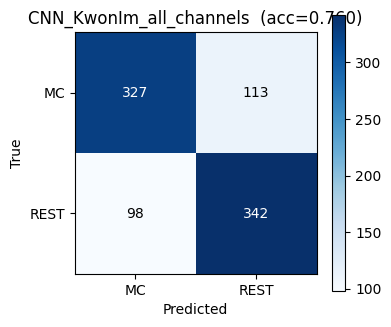

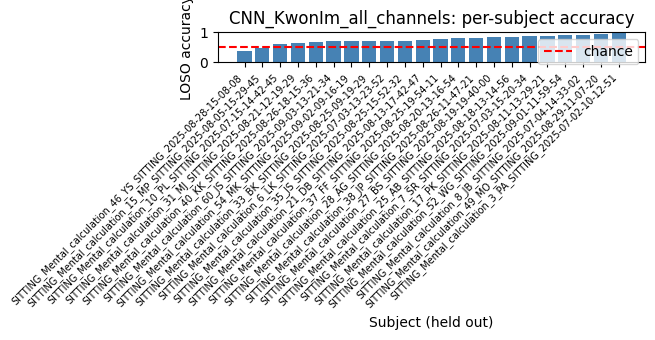

{
  "method": "CNN_KwonIm_all_channels",
  "accuracy": 0.7602272727272728,
  "balanced_accuracy": 0.7602272727272728,
  "f1_macro": 0.7601575871088577,
  "f1_MC": 0.7560693641618497,
  "recall_MC": 0.7431818181818182,
  "precision_MC": 0.7694117647058824,
  "n": 880,
  "roc_auc": 0.8453150826446281,
  "n_subjects": 22,
  "mean_acc_over_subjects": 0.7602272727272726,
  "std_acc_over_subjects": 0.1505266727885102,
  "pooled_acc": 0.7602272727272728,
  "p_value_vs_chance": null
}

✓ Zapisano do: /Users/antek/Desktop/Praca Magisterska kody/LOSO/CNN_KwonIm_all_channels


In [7]:
#Podejście oparte o CNN
import tensorflow as tf
import os
import time
import numpy as np

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D, BatchNormalization, ReLU,
    Dropout, Flatten, Dense, Input
)
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"


SEED = 320768
np.random.seed(SEED)
tf.random.set_seed(SEED)

BATCH_SIZE    = 100
LR            = 0.0005
DECAY         = 5e-8
DROPOUT_RATE  = 0.5
EPOCHS_MAX    = 200
PATIENCE      = 20
VAL_SPLIT     = 0.10

CNN_CONV1_F = 32
CNN_CONV1_K = 13
CNN_CONV1_S = 9

CNN_CONV2_F = 32
CNN_CONV2_K = 6
CNN_CONV2_S = 4


def zscore_time_normalize(X):
    mean = X.mean(axis=-1, keepdims=True)
    std = X.std(axis=-1, keepdims=True) + 1e-8
    return (X - mean) / std


def reshape_for_1dcnn(X):
    X_t = np.transpose(X, (0, 3, 1, 2))      
    X_cnn = X_t.reshape(X_t.shape[0], X_t.shape[1], -1)  
    return X_cnn


def build_cnn_kwon(input_shape, n_classes=2):
    model = Sequential([
        Input(shape=input_shape),

        BatchNormalization(),
        ReLU(),
        Dropout(DROPOUT_RATE),

        Conv1D(
            filters=CNN_CONV1_F,
            kernel_size=CNN_CONV1_K,
            strides=CNN_CONV1_S,
            padding="valid"
        ),
        BatchNormalization(),
        ReLU(),
        Dropout(DROPOUT_RATE),

        Conv1D(
            filters=CNN_CONV2_F,
            kernel_size=CNN_CONV2_K,
            strides=CNN_CONV2_S,
            padding="valid"
        ),
        BatchNormalization(),
        ReLU(),
        Dropout(DROPOUT_RATE),

        Flatten(),

        Dense(
            n_classes,
            activation="softmax",
            kernel_initializer="he_normal"
        ),
    ])

    optimizer = Adamax(learning_rate=LR, decay=DECAY)

    model.compile(
        optimizer=optimizer,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


def fp_cnn(X_tr, y_tr, X_te):
    X_tr_n = zscore_time_normalize(X_tr)
    X_te_n = zscore_time_normalize(X_te)

    X_tr_cnn = reshape_for_1dcnn(X_tr_n).astype(np.float32)
    X_te_cnn = reshape_for_1dcnn(X_te_n).astype(np.float32)

    label_map = {
        "MC": 0,
        "REST": 1,
    }

    y_tr_int = np.array([label_map[l] for l in y_tr])
    y_tr_cat = to_categorical(y_tr_int, num_classes=2)

    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED)

    model = build_cnn_kwon(input_shape=X_tr_cnn.shape[1:])

    es = EarlyStopping(
        monitor="val_loss",
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=0
    )

    model.fit(
        X_tr_cnn,
        y_tr_cat,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS_MAX,
        validation_split=VAL_SPLIT,
        callbacks=[es],
        verbose=0
    )

    proba_all = model.predict(X_te_cnn, verbose=0)

    y_pred_int = proba_all.argmax(axis=1)

    inv_label = {
        0: "MC",
        1: "REST",
    }

    y_pred = np.array([inv_label[i] for i in y_pred_int])
    y_proba = proba_all[:, 0]  # prawdopodobieństwo klasy MC

    return {
        "y_pred": y_pred,
        "y_proba": y_proba,
    }


N_CHANNELS_USED = X_all.shape[2]
CHANNEL_NAMES_USED = common_channels


t0 = time.time()

res_cnn = run_loso(
    X_all,
    y_all,
    subj_all,
    fp_cnn,
    method_name="CNN_KwonIm_all_channels",
    need_proba=True
)

total_time = time.time() - t0

print(f"[CNN] pooled accuracy         = {res_cnn['pooled_acc']:.4f}")

summary_cnn = plot_and_save(
    res_cnn,
    perm_null=None,
    p_value=None,
    channel_importance=None,
    channels=CHANNEL_NAMES_USED,
    outdir=OUTDIR,
)

print(f"\n✓ Zapisano do: {OUTDIR / 'CNN_KwonIm_all_channels'}")

In [8]:
#Podejście oparte o sLDA

import numpy as np
import pandas as pd
import time

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

WINDOWS_SEC = [(0.0, 5.0), (5.0, 10.0), (10.0, 15.0)]
EPOCH_TMIN = 0.0 
EPOCH_TMAX = 15.0  
CHROMO_NAME = "HbO+HbR"
CHROMO_IDX = [0, 1]   


def _sample_bounds_from_time(n_samples, tmin, tmax, win_start, win_end):
    total = tmax - tmin
    i0 = int(round((win_start - tmin) / total * (n_samples - 1)))
    i1 = int(round((win_end   - tmin) / total * (n_samples - 1)))
    i0 = max(0, min(i0, n_samples - 1))
    i1 = max(i0 + 1, min(i1, n_samples))  
    return i0, i1


def extract_slda_features(X):
    X_sel = X[:, CHROMO_IDX, :, :] 
    n_samples = X_sel.shape[-1]

    feats = []
    for (ws, we) in WINDOWS_SEC:
        i0, i1 = _sample_bounds_from_time(n_samples, EPOCH_TMIN, EPOCH_TMAX, ws, we)
        win_mean = X_sel[..., i0:i1].mean(axis=-1) 
        feats.append(win_mean)

    feats = np.stack(feats, axis=1)      
    F = feats.reshape(feats.shape[0], -1)  

    F = np.nan_to_num(F, nan=0.0, posinf=0.0, neginf=0.0)

    return F


def build_sLDA():
    return LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")


def fit_predict_slda(X_tr, y_tr, X_te):
    F_tr = extract_slda_features(X_tr)
    F_te = extract_slda_features(X_te)

    model = build_sLDA()
    model.fit(F_tr, y_tr)

    y_pred = model.predict(F_te)

    try:
        proba_all = model.predict_proba(F_te)
        classes = list(model.classes_)
        proba = proba_all[:, classes.index("MC")] if "MC" in classes else proba_all[:, 0]
    except Exception:
        proba = None

    return {
        "y_pred": y_pred,
        "y_proba": proba,
    }


n_feat = len(WINDOWS_SEC) * len(CHROMO_IDX) * X_all.shape[2]

t0 = time.time()

res_slda = run_loso(
    X_all,
    y_all,
    subj_all,
    fit_predict_slda,
    method_name="sLDA_Kwon",
    need_proba=True,
)

elapsed = time.time() - t0

per_df = res_slda["per_subject"]

out_single = OUTDIR / "kwon_sLDA"
out_single.mkdir(parents=True, exist_ok=True)

per_df.to_csv(out_single / "per_subject_sLDA_Kwon.csv", index=False)

summary = {
    "method": "sLDA_Kwon",
    "features": "mean_windows_0-5_5-10_10-15s",
    "chromo": CHROMO_NAME,
    "n_windows": len(WINDOWS_SEC),
    "n_channels": int(X_all.shape[2]),
    "n_features_total": int(n_feat),
    "pooled_acc": float(res_slda["pooled_acc"]),
    "per_subject_mean_acc": float(per_df["accuracy"].mean()) if len(per_df) else np.nan,
    "per_subject_std_acc": float(per_df["accuracy"].std()) if len(per_df) else np.nan,
    "per_subject_mean_bal_acc": float(per_df["balanced_accuracy"].mean()) if len(per_df) else np.nan,
}

pd.DataFrame([summary]).to_csv(out_single / "summary_sLDA_Kwon.csv", index=False)

In [9]:
#Porownanie 6 metod - opartych o GLM i pozostalych

import numpy as np
import pandas as pd
import re
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import combinations
from scipy import stats

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score

OUTDIR_RES = Path(r"/Users/antek/Desktop/Praca Magisterska kody/LOSO Results")
OUTDIR_BET = OUTDIR_RES / "betas"
OUTDIR_CMP = OUTDIR / "porownanie_6metod"        
OUTDIR_CMP.mkdir(parents=True, exist_ok=True)

HRF_NAME  = "Gamma_t2_s4"
DRIFT     = 0
POS_LABEL = "MC"

GLM_METHODS = [          
    ("OLS",     "GLM OLS"),
    ("OLS_SS",  "GLM OLS+SS"),
    ("AR_IRLS", "GLM AR-IRLS"),
]

MEM_METHODS = [          
    (res_lda_mean_peak_hbo, "LDA (Naseer)"),
    (res_slda,              "sLDA (Kwon)"),
    (res_cnn,               "CNN (Kwon&Im)"),
]

def beta_path(nm):
    return OUTDIR_BET / f"{nm}__{HRF_NAME}__d{DRIFT}.csv"

def make_slda():
    return Pipeline([("sc", StandardScaler()),
                     ("clf", LinearDiscriminantAnalysis(solver="lsqr",
                                                        shrinkage="auto"))])

def norm_id(x):
    s = str(x).strip()
    m = re.search(r"\d+", s)
    return str(int(m.group())) if m else s

def run_loso(df, pipe):
    bc = [c for c in df.columns if c.startswith("b") and c[1:].isdigit()]
    rows = []
    for s in df["subject"].unique():
        te = df["subject"] == s
        X_tr = df.loc[~te, bc].values.astype(float); y_tr = df.loc[~te, "label"].values
        X_te = df.loc[ te, bc].values.astype(float); y_te = df.loc[ te, "label"].values
        ok_tr = np.all(np.isfinite(X_tr), axis=1); ok_te = np.all(np.isfinite(X_te), axis=1)
        X_tr, y_tr = X_tr[ok_tr], y_tr[ok_tr]; X_te, y_te = X_te[ok_te], y_te[ok_te]
        if len(np.unique(y_tr)) < 2 or len(y_te) == 0:
            continue
        try:
            pipe.fit(X_tr, y_tr); y_pred = pipe.predict(X_te)
        except Exception:
            continue
        rows.append({"subject": norm_id(s),
                     "accuracy": accuracy_score(y_te, y_pred)})
    return pd.DataFrame(rows)

try:
    _tmp = pd.read_csv(beta_path("OLS"))
    ids_csv = sorted({norm_id(s) for s in _tmp["subject"].unique()})
    print(f"  ID z pliku beta (OLS):  {ids_csv}")
except Exception as e:
    print(f"  [nie udalo sie wczytac pliku beta]: {e}")
ids_mem = sorted({norm_id(s) for s in res_slda["per_subject"]["subject"].unique()})


per_subj = {}  

for nm_key, nm_lbl in GLM_METHODS:
    fp = beta_path(nm_key)
    if not fp.exists():
        print(f"  [BRAK PLIKU] {fp.name} -- pomijam {nm_lbl}")
        continue
    df_b = pd.read_csv(fp)
    res  = run_loso(df_b, make_slda())
    per_subj[nm_lbl] = res.set_index("subject")["accuracy"]


for res_obj, nm_lbl in MEM_METHODS:
    dfp = res_obj["per_subject"].copy()
    idx = dfp["subject"].map(norm_id)
    s = pd.Series(dfp["accuracy"].values, index=idx.values)
    per_subj[nm_lbl] = s

acc_wide = pd.concat(per_subj, axis=1).dropna()
method_names = list(acc_wide.columns)
subjects_raw = list(acc_wide.index)
N, k = acc_wide.shape


pacjent_map = {s: f"Pacjent {i+1}" for i, s in enumerate(subjects_raw)}
acc_disp = acc_wide.rename(index=pacjent_map)
acc_disp.to_csv(OUTDIR_CMP / "accuracy_per_pacjent.csv")


desc = pd.DataFrame({
    "mean":   acc_wide.mean(),
    "std":    acc_wide.std(),
    "median": acc_wide.median(),
    "IQR":    acc_wide.quantile(.75) - acc_wide.quantile(.25),
    "min":    acc_wide.min(),
    "max":    acc_wide.max(),
}).sort_values("mean", ascending=False)

best_method = desc.index[0]
desc.to_csv(OUTDIR_CMP / "statystyki_opisowe.csv")

rank_matrix = acc_wide.rank(axis=1, ascending=False)
rank_disp   = rank_matrix.rename(index=pacjent_map)
rank_disp.to_csv(OUTDIR_CMP / "macierz_rang.csv")


T_stat, p_fried = stats.friedmanchisquare(*[acc_wide[m].values for m in method_names])
df_fried = k - 1
kendall_w = T_stat / (N * (k - 1))
mean_ranks = rank_matrix.mean().sort_values()

R = rank_matrix.sum(axis=0)
T_manual = (12.0 / (N * k * (k + 1))) * (R**2).sum() - 3 * N * (k + 1)
T_crit   = stats.chi2.ppf(0.95, df_fried)

print("\n" + "="*72)
print("  TEST FRIEDMANA  (H0: wszystkie metody daja ten sam rozklad accuracy)")
print("="*72)
print(f"  N (pacjenci)               = {N}")
print(f"  k (metody)                 = {k}")
print(f"  Wartosc statystyki test. T = {T_stat:.4f}")
print(f"  df                         = {df_fried}")
print(f"  p-value                    = {p_fried:.4g}")
print(f"  Wartosc krytyczna T_0.05(df={df_fried}) = {T_crit:.3f}")
print(f"  T (ze wzoru, bez korekty na rangi wiazane) = {T_manual:.4f}")


import scikit_posthocs as sp
nemenyi = sp.posthoc_nemenyi_friedman(acc_wide.values)
nemenyi.index = method_names
nemenyi.columns = method_names
_src = "scikit-posthocs"

print("\n" + "="*72)
print(f"  POST-HOC NEMENYI -- MACIERZ p-WARTOSCI  (zrodlo: {_src})")
print("="*72)
print(nemenyi.round(4).to_string())
nemenyi.to_csv(OUTDIR_CMP / "nemenyi_pvalues.csv")

sig_rows = []
for a, b in combinations(method_names, 2):
    p = nemenyi.loc[a, b]
    sig_rows.append({
        "porownanie": f"{a}  vs  {b}",
        "mean_diff":  acc_wide[a].mean() - acc_wide[b].mean(),
        "rank_a": mean_ranks[a], "rank_b": mean_ranks[b],
        "p_nemenyi": p,
        "istotne_0.05": p < 0.05,
    })
sig = pd.DataFrame(sig_rows).sort_values("p_nemenyi")
sig.to_csv(OUTDIR_CMP / "nemenyi_pary.csv", index=False)

from scipy.stats import studentized_range
q_alpha = studentized_range.ppf(0.95, k, np.inf)
CD = q_alpha * np.sqrt(k * (k + 1) / (6.0 * N))


_palette = ["#378ADD", "#1D9E75", "#D85A30", "#9B59B6", "#E8B92F", "#5D6D7E"]
_colors = {m: _palette[i % len(_palette)] for i, m in enumerate(method_names)}
cols = [_colors[m] for m in method_names]

fig, ax = plt.subplots(figsize=(max(10, N*1.3), 5.5))
x = np.arange(N); w = 0.8 / k
for j, m in enumerate(method_names):
    ax.bar(x + (j - (k-1)/2)*w, acc_disp[m].values, w, label=m,
           color=_colors[m], alpha=.88, edgecolor="white", linewidth=.4)
ax.axhline(0.5, color="red", ls="--", lw=1, label="poziom losowy")
ax.set_xticks(x); ax.set_xticklabels(acc_disp.index, rotation=35, ha="right")
ax.set_ylabel("LOSO accuracy"); ax.set_ylim(0, 1.05)
ax.set_title("Accuracy per pacjent -- 6 metod (LOSO)")
ax.legend(ncol=3, fontsize=8); plt.tight_layout()
fig.savefig(OUTDIR_CMP / "fig_accuracy_per_pacjent.pdf"); plt.close(fig)


fig, ax = plt.subplots(figsize=(9, 5.5))
data = [acc_wide[m].values for m in method_names]
bp = ax.boxplot(data, labels=method_names, showmeans=True, patch_artist=True)
for patch, c in zip(bp["boxes"], cols):
    patch.set_facecolor(c); patch.set_alpha(.35)
for j, m in enumerate(method_names):
    ax.scatter(np.full(N, j+1) + np.random.uniform(-.06, .06, N),
               acc_wide[m].values, color=_colors[m], s=20, zorder=3, alpha=.8)
ax.axhline(0.5, color="red", ls="--", lw=1)
ax.set_ylabel("LOSO accuracy"); ax.set_ylim(0, 1)
ax.set_title("Rozklad accuracy -- 6 metod (LOSO)")
plt.xticks(rotation=20, ha="right"); plt.tight_layout()
fig.savefig(OUTDIR_CMP / "fig_boxplot_accuracy.pdf"); plt.close(fig)


fig, ax = plt.subplots(figsize=(9, 5.5))
for s in acc_disp.index:
    ax.plot(range(k), acc_disp.loc[s, method_names].values,
            marker="o", lw=1, alpha=.4)
ax.plot(range(k), [acc_wide[m].mean() for m in method_names],
        "k-o", lw=3, label="srednia")
ax.set_xticks(range(k)); ax.set_xticklabels(method_names, rotation=20, ha="right")
ax.set_ylabel("LOSO accuracy"); ax.set_ylim(0, 1)
ax.set_title("Parowane wyniki pacjentow miedzy 6 metodami")
ax.legend(); plt.tight_layout()
fig.savefig(OUTDIR_CMP / "fig_paired_lines.pdf"); plt.close(fig)

fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(nemenyi.values, cmap="RdYlGn_r", vmin=0, vmax=0.1)
ax.set_xticks(range(k)); ax.set_xticklabels(method_names, rotation=40, ha="right", fontsize=8)
ax.set_yticks(range(k)); ax.set_yticklabels(method_names, fontsize=8)
for i in range(k):
    for j in range(k):
        val = nemenyi.values[i, j]
        ax.text(j, i, f"{val:.3f}", ha="center", va="center",
                fontsize=7, color="black" if val > 0.05 else "white")
ax.set_title("Post-hoc Nemenyi -- p-wartosci (zielone = istotne <0.05)")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="p-value")
plt.tight_layout()
fig.savefig(OUTDIR_CMP / "fig_nemenyi_heatmap.pdf"); plt.close(fig)


  ID z pliku beta (OLS):  ['10', '15', '17', '21', '25', '27', '28', '3', '31', '33', '35', '37', '38', '40', '46', '49', '52', '54', '6', '60', '7', '8']

  TEST FRIEDMANA  (H0: wszystkie metody daja ten sam rozklad accuracy)
  N (pacjenci)               = 22
  k (metody)                 = 6
  Wartosc statystyki test. T = 26.2215
  df                         = 5
  p-value                    = 8.083e-05
  Wartosc krytyczna T_0.05(df=5) = 11.070
  T (ze wzoru, bez korekty na rangi wiazane) = 25.3701

  POST-HOC NEMENYI -- MACIERZ p-WARTOSCI  (zrodlo: scikit-posthocs)
               GLM OLS  GLM OLS+SS  GLM AR-IRLS  LDA (Naseer)  sLDA (Kwon)  CNN (Kwon&Im)
GLM OLS         1.0000      0.9666       0.6441        0.5101       0.9837         0.0267
GLM OLS+SS      0.9666      1.0000       0.9789        0.1131       1.0000         0.2123
GLM AR-IRLS     0.6441      0.9789       1.0000        0.0140       0.9588         0.6441
LDA (Naseer)    0.5101      0.1131       0.0140        1.0000      